# 散点图

# 使用折线图直方图显示分布情况

<Figure size 1000x800 with 0 Axes>

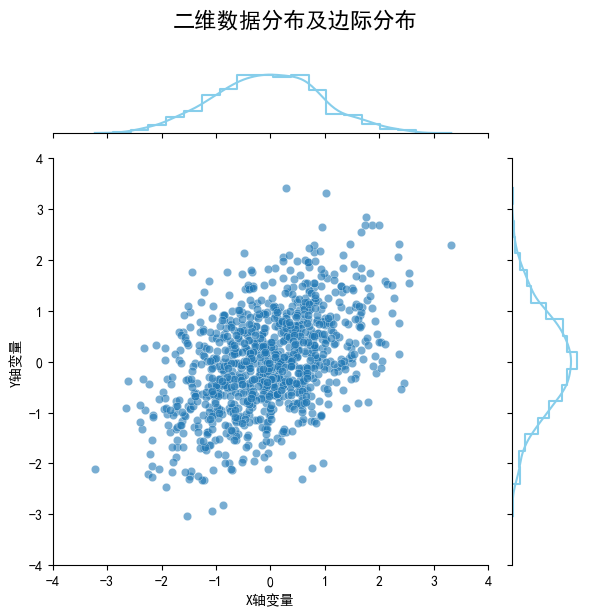

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False
# 设置随机种子保证可重复性
np.random.seed(42)
 
# 生成示例数据（二维正态分布）
mean = [0, 0]
cov = [[1, 0.5], [0.5, 1]]  # 协方差矩阵
x, y = np.random.multivariate_normal(mean, cov, 1000).T
 
# 创建画布和子图布局
plt.figure(figsize=(10, 8), facecolor='white')
 
# 使用Seaborn的jointplot绘制组合图
# kind参数可选：'scatter'（散点图）或'kde'（核密度估计）
g = sns.JointGrid(
    x=x,
    y=y,
    marginal_ticks=False  # 隐藏边际图的刻度
)
 
# 绘制散点图（主图）
g.plot_joint(
    sns.scatterplot,
    alpha=0.6,          # 点透明度
    edgecolor='w',      # 点边缘颜色
    linewidth=0.3       # 边缘线宽
)
 
# 绘制边际直方图（可选kde）
g.plot_marginals(
    sns.histplot,
    bins=20,            # 直方图柱数
    kde=True,           # 显示核密度估计曲线
    color='skyblue',    # 直方图颜色
    element='step',     # 直方图样式（阶梯状）
    fill=False          # 不填充颜色
)
 
# 添加图形装饰
plt.suptitle('二维数据分布及边际分布', y=1.02, fontsize=16)
g.ax_joint.set(
    xlabel='X轴变量',
    ylabel='Y轴变量',
    xlim=(-4, 4),
    ylim=(-4, 4)
)
 
# 调整布局
plt.tight_layout()
plt.show()

# 使用直方图显示分布情况

C:\Users\wen\AppData\Local\Temp\ipykernel_52408\3201249781.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # 自动调整布局
C:\Users\wen\AppData\Local\Temp\ipykernel_52408\3201249781.py:73: UserWarning: The figure layout has changed to tight
  plt.tight_layout()  # 自动调整布局


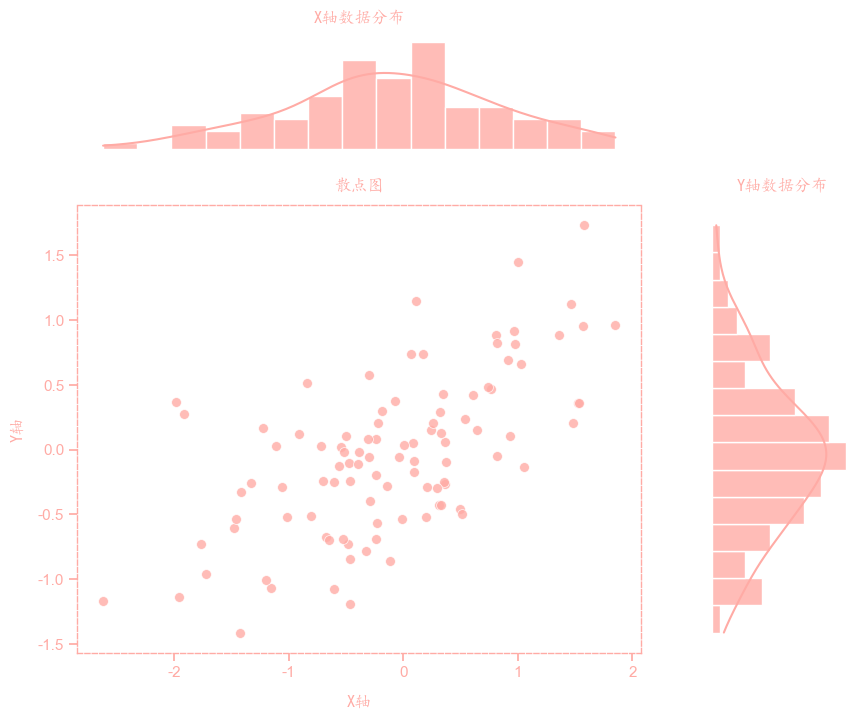

In [132]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.font_manager as fm
# 设置字体路径
font_path = r'../simkai.ttf'  # Windows示例
 
# 加载字体并设置
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子以确保结果可重复
np.random.seed(42)
color = '#ffaba5'
# 生成示例数据
x = np.random.normal(loc=0, scale=1, size=100)  # x轴数据：正态分布
y = 0.5 * x + np.random.normal(loc=0, scale=0.5, size=100)  # y轴数据：与x轴线性相关

# 设置图形参数
plt.figure(figsize=(10, 8), constrained_layout=True)  # 设置画布大小
# sns.set(style='whitegrid')  # 使用 Seaborn 的白色网格风格
sns.set(style='ticks')

# 定义网格布局
grid = plt.GridSpec(4, 4, hspace=0.5, wspace=0.5)  # 4x4网格，设置间距

# 绘制散点图
ax_main = plt.subplot(grid[1:4, 0:3])  # 主图区域
sns.scatterplot(
    x=x, y=y,
    color=color,  # 散点颜色：蓝色
    s=50,  # 散点大小
    alpha=0.8  # 透明度
)
ax_main.set_title('散点图', fontsize=14, fontweight='bold', pad=10, fontproperties=font_prop, color=color)  # 主图标题
ax_main.set_xlabel('X轴', fontsize=12, labelpad=10, fontproperties=font_prop, color=color)  # x轴标签
ax_main.set_ylabel('Y轴', fontsize=12, labelpad=10, fontproperties=font_prop, color=color)  # y轴标签

# 设置坐标轴的颜色和线型
for spine in ax_main.spines.values():
    spine.set_color(color)  # 设置坐标轴线颜色为红色
    spine.set_linewidth(1)  # 设置坐标轴线宽度为 2
    spine.set_linestyle('--')  # 设置坐标轴线型为虚线
ax_main.tick_params(colors=color)
# 绘制x轴数据分布直方图
ax_x_dist = plt.subplot(grid[0, 0:3])  # x轴分布区域
sns.histplot(
    x=x,
    color=color,  # 直方图颜色：橙色
    kde=True,  # 显示核密度估计曲线
    bins=15,  # 直方图分箱数
    alpha=0.8  # 透明度
)
ax_x_dist.set_title('X轴数据分布', fontsize=12, pad=10, fontproperties=font_prop, color=color)  # x轴分布标题
ax_x_dist.set_xlabel('', fontproperties=font_prop, color=color)  # 隐藏x轴标签
ax_x_dist.set_ylabel('频数', fontsize=10, fontproperties=font_prop, color=color)  # y轴标签
ax_x_dist.axis('off')
# 绘制y轴数据分布直方图
ax_y_dist = plt.subplot(grid[1:4, 3])  # y轴分布区域
sns.histplot(
    y=y,
    color=color,  # 直方图颜色：绿色
    kde=True,  # 显示核密度估计曲线
    bins=15,  # 直方图分箱数
    alpha=0.8  # 透明度
)
ax_y_dist.set_title('Y轴数据分布', fontsize=12, pad=10, fontproperties=font_prop, color=color)  # y轴分布标题
ax_y_dist.set_ylabel('', fontproperties=font_prop, color=color)  # 隐藏y轴标签
ax_y_dist.set_xlabel('频数', fontsize=10, fontproperties=font_prop, color=color)  # x轴标签
ax_y_dist.axis('off') 
# 显示图形
plt.tight_layout()  # 自动调整布局
plt.savefig('scatter_1.png', dpi=400)
plt.show()

D:\Anaconda3\install\envs\data_view\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


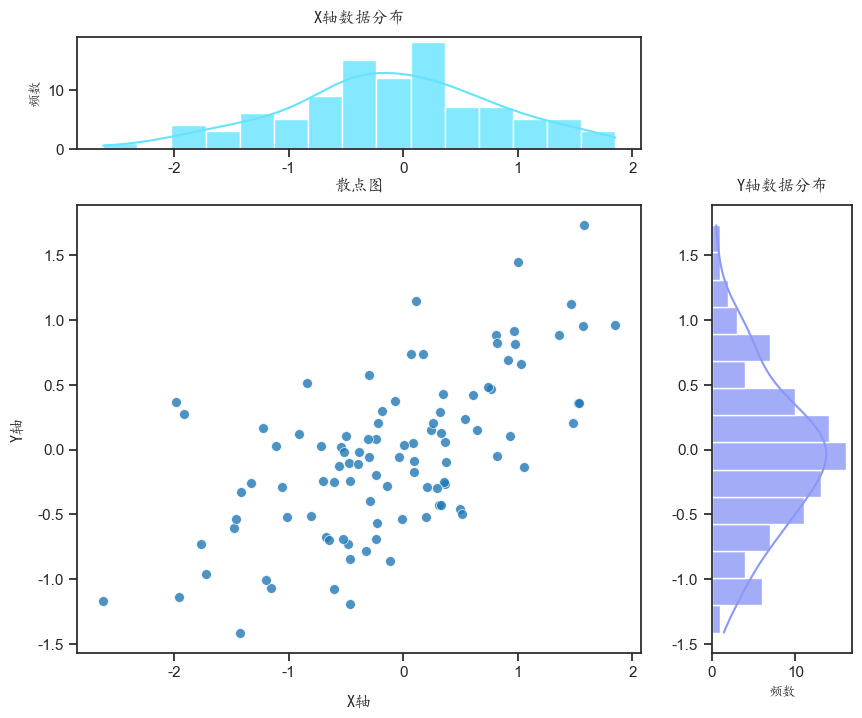

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.font_manager as fm
font_path = r'../simkai.ttf'  # Windows示例
 
# 加载字体并设置
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False
# 设置随机种子以确保结果可重复
np.random.seed(42)

# 生成示例数据
x = np.random.normal(loc=0, scale=1, size=100)  # x轴数据：正态分布
y = 0.5 * x + np.random.normal(loc=0, scale=0.5, size=100)  # y轴数据：与x轴线性相关

# 设置支持中文的字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 设置图形参数
plt.figure(figsize=(10, 8), constrained_layout=True)  # 使用 constrained_layout
sns.set(style='ticks')  # 使用 Seaborn 的 ticks 风格（无网格线）

# 定义网格布局
grid = plt.GridSpec(4, 4, hspace=0.5, wspace=0.5)  # 4x4网格，设置间距

# 绘制散点图
ax_main = plt.subplot(grid[1:4, 0:3])  # 主图区域
sns.scatterplot(
    x=x, y=y,
    color='#1f77b4',  # 散点颜色：蓝色
    s=50,  # 散点大小
    alpha=0.8  # 透明度
)
ax_main.set_title('散点图', fontsize=14, fontweight='bold', pad=10, fontproperties=font_prop)  # 主图标题
ax_main.set_xlabel('X轴', fontsize=12, labelpad=10, fontproperties=font_prop)  # x轴标签
ax_main.set_ylabel('Y轴', fontsize=12, labelpad=10, fontproperties=font_prop)  # y轴标签

# 绘制x轴数据分布直方图
ax_x_dist = plt.subplot(grid[0, 0:3])  # x轴分布区域
sns.histplot(
    x=x,
    color='#66e3ff',  # 直方图颜色：橙色
    kde=True,  # 显示核密度估计曲线
    bins=15,  # 直方图分箱数
    alpha=0.8  # 透明度
)
ax_x_dist.set_title('X轴数据分布', fontsize=12, pad=10, fontproperties=font_prop)  # x轴分布标题
ax_x_dist.set_xlabel('', fontproperties=font_prop)  # 隐藏x轴标签
ax_x_dist.set_ylabel('频数', fontsize=10, fontproperties=font_prop)  # y轴标签

# 绘制y轴数据分布直方图
ax_y_dist = plt.subplot(grid[1:4, 3])  # y轴分布区域
sns.histplot(
    y=y,
    color='#8b98f6',  # 直方图颜色：绿色
    kde=True,  # 显示核密度估计曲线
    bins=15,  # 直方图分箱数
    alpha=0.8  # 透明度
)
ax_y_dist.set_title('Y轴数据分布', fontsize=12, pad=10, fontproperties=font_prop)  # y轴分布标题
ax_y_dist.set_ylabel('', fontproperties=font_prop)  # 隐藏y轴标签
ax_y_dist.set_xlabel('频数', fontsize=10, fontproperties=font_prop)  # x轴标签

# 移除所有网格线
ax_main.grid(False)  # 关闭散点图的网格线
ax_x_dist.grid(False)  # 关闭x轴分布直方图的网格线
ax_y_dist.grid(False)  # 关闭y轴分布直方图的网格线

# 显示图形
plt.show()

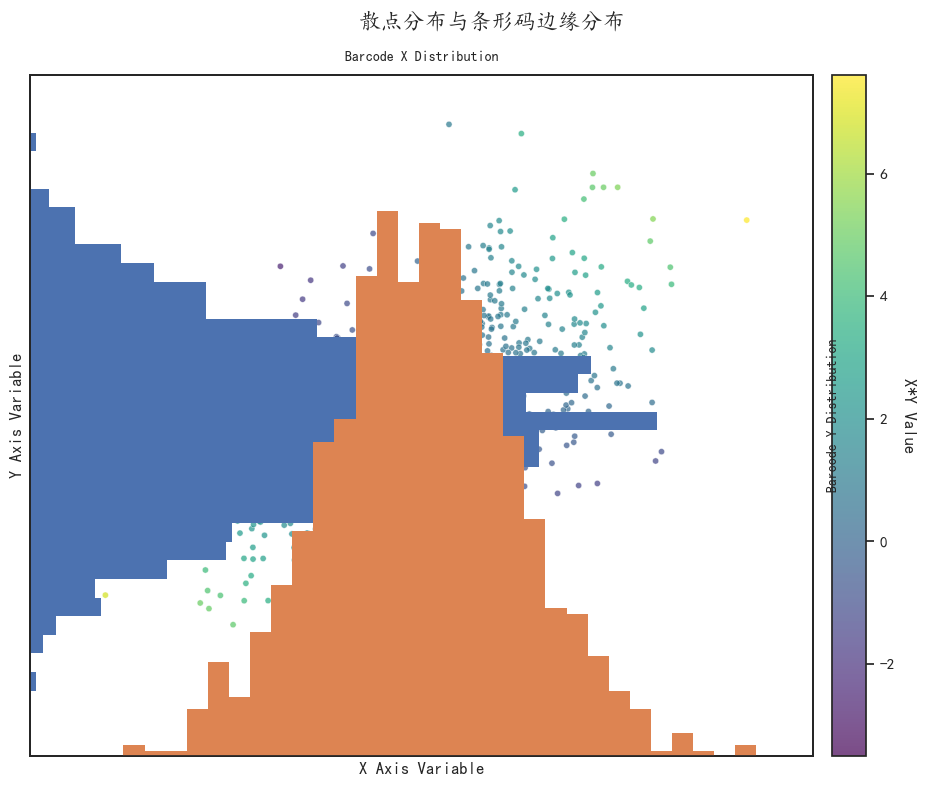

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
font_path = r'../simkai.ttf'  # Windows示例
 
# 加载字体并设置
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False
# 设置随机种子和配色方案
np.random.seed(42)
sns.set_palette("husl")  # 使用HUSL调色板，保证色盲友好且美观
 
# 生成示例数据（二维正态分布）
mean = [0, 0]
cov = [[1, 0.5], [0.5, 1]]
x, y = np.random.multivariate_normal(mean, cov, 1000).T
 
# 创建画布和布局
plt.figure(figsize=(10, 8), facecolor='white')
plt.suptitle('散点分布与条形码边缘分布', y=0.98, fontsize=16)
 
# 主散点图
ax_main = plt.gca()
scatter = ax_main.scatter(
    x, y,
    s=20,          # 点大小
    alpha=0.7,     # 透明度
    edgecolor='w', # 边缘颜色
    linewidth=0.4, # 边缘线宽
    c=x*y,         # 颜色映射（示例用x*y作为第三维）
    cmap='viridis' # 连续色图
)
 
# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax_main, pad=0.02)
cbar.set_label('X*Y Value', rotation=270, labelpad=15)
 
# 创建条形编码分布函数
def create_barcode(ax, data, orientation, bins=20, color='skyblue'):
    """
    创建条形码风格分布图
    参数：
        ax - 坐标轴对象
        data - 数据数组
        orientation - 方向 ('horizontal' 或 'vertical')
        bins - 分箱数量
        color - 条形颜色
    """
    counts, edges = np.histogram(data, bins=bins)
    
    # 归一化计数到[0,1]范围
    norm_counts = counts / counts.max()
    
    # 计算条形位置
    if orientation == 'horizontal':
        y = np.zeros_like(counts)
        height = norm_counts * 0.8  # 控制最大高度
        ax.barh(edges[:-1], height, height=np.diff(edges), 
                left=y, align='edge', color=color, linewidth=0)
        ax.set_xlim(0, 1)
    else:
        x = np.zeros_like(counts)
        width = norm_counts * 0.8
        ax.bar(edges[:-1], width, width=np.diff(edges),
                bottom=x, align='edge', color=color, linewidth=0)
        ax.set_ylim(0, 1)
 
    # 隐藏坐标轴刻度
    ax.set(xticks=[], yticks=[])
 
# 创建边缘坐标轴
ax_top = ax_main.twiny()
ax_right = ax_main.twinx()
 
# 绘制条形码分布
create_barcode(ax_top, x, 'horizontal', bins=30, color='#4C72B0')  # 蓝色系
create_barcode(ax_right, y, 'vertical', bins=30, color='#DD8452')   # 橙色系
 
# 调整布局和样式
ax_main.set(
    xlabel='X Axis Variable',
    ylabel='Y Axis Variable',
    xlim=(-4, 4),
    ylim=(-4, 4)
)
ax_top.set_xlabel('Barcode X Distribution', fontsize=10, labelpad=10)
ax_right.set_ylabel('Barcode Y Distribution', fontsize=10, labelpad=10)
 
plt.tight_layout()
plt.show()

# 使用条形图展示分布情况

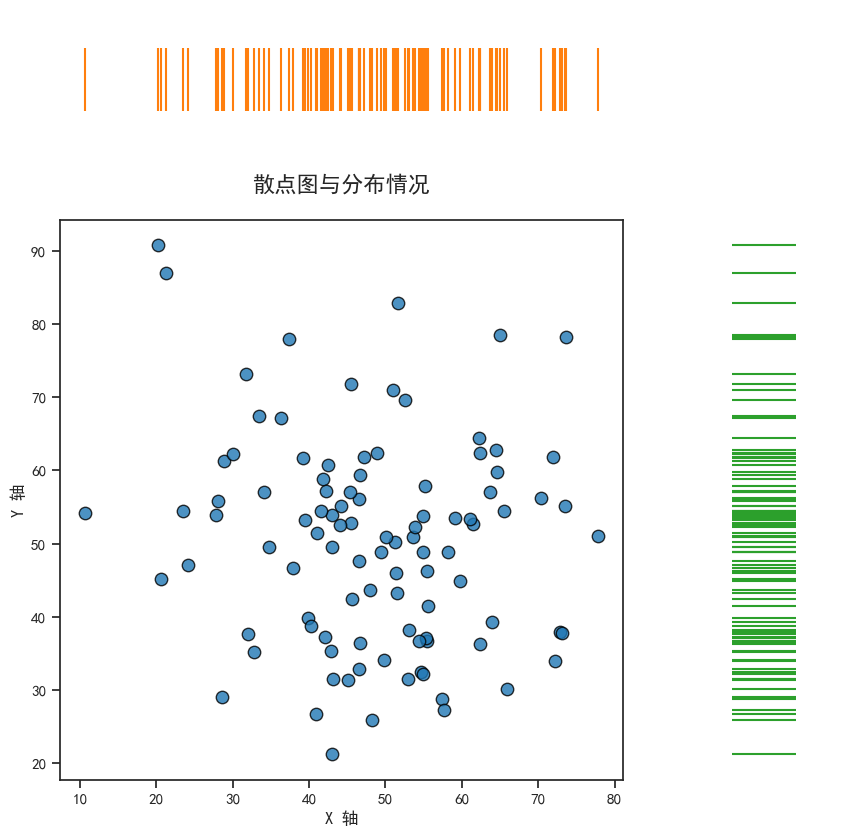

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.family'] = 'SimHei'

# 生成示例数据
np.random.seed(42)
x = np.random.normal(50, 15, 100)  # x 轴数据
y = np.random.normal(50, 15, 100)  # y 轴数据

# 创建画布和子图布局
fig = plt.figure(figsize=(10, 10))
grid = plt.GridSpec(4, 4, hspace=0.5, wspace=0.5)

# 主散点图
ax_main = fig.add_subplot(grid[1:4, 0:3])
ax_main.scatter(x, y, color='#1f77b4', alpha=0.8, edgecolor='black', s=80)
ax_main.set_xlabel('X 轴', fontsize=12)
ax_main.set_ylabel('Y 轴', fontsize=12)
ax_main.set_title('散点图与分布情况', fontsize=16, pad=20)

# X 轴分布条形码
ax_x_dist = fig.add_subplot(grid[0, 0:3])
ax_x_dist.eventplot(x, orientation='horizontal', colors='#ff7f0e', lineoffsets=0.5, linelengths=0.8)
ax_x_dist.set_xlim(ax_main.get_xlim())  # 与主图 x 轴范围一致
ax_x_dist.axis('off')  # 隐藏坐标轴

# Y 轴分布条形码
ax_y_dist = fig.add_subplot(grid[1:4, 3])
ax_y_dist.eventplot(y, orientation='vertical', colors='#2ca02c', lineoffsets=0.5, linelengths=0.8)
ax_y_dist.set_ylim(ax_main.get_ylim())  # 与主图 y 轴范围一致
ax_y_dist.axis('off')  # 隐藏坐标轴

# 显示图形
plt.show()

# 子图和主图发生重叠，需调整位置

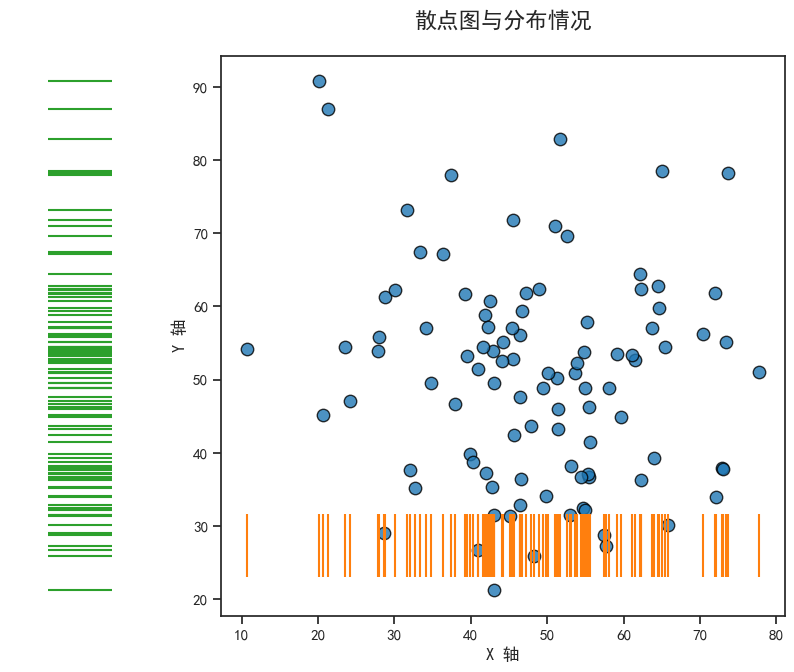

In [117]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.family'] = 'SimHei'

# 生成示例数据
np.random.seed(42)
x = np.random.normal(50, 15, 100)  # x 轴数据
y = np.random.normal(50, 15, 100)  # y 轴数据

# 创建画布和子图布局
fig = plt.figure(figsize=(10, 10))
grid = plt.GridSpec(4, 4, hspace=0.5, wspace=0.5)

# 主散点图
ax_main = fig.add_subplot(grid[1:4, 1:4])  # 占据第1到第3行，第1到第3列
ax_main.scatter(x, y, color='#1f77b4', alpha=0.8, edgecolor='black', s=80)
ax_main.set_xlabel('X 轴', fontsize=12)
ax_main.set_ylabel('Y 轴', fontsize=12)
ax_main.set_title('散点图与分布情况', fontsize=16, pad=20)

# X 轴分布条形码（调整到下边）
ax_x_dist = fig.add_subplot(grid[3, 1:4])  # 占据第3行，第1到第3列
ax_x_dist.eventplot(x, orientation='horizontal', colors='#ff7f0e', lineoffsets=0.5, linelengths=0.8)
ax_x_dist.set_xlim(ax_main.get_xlim())  # 与主图 x 轴范围一致
ax_x_dist.axis('off')  # 隐藏坐标轴

# Y 轴分布条形码（调整到左边）
ax_y_dist = fig.add_subplot(grid[1:4, 0])  # 占据第1到第3行，第0列
ax_y_dist.eventplot(y, orientation='vertical', colors='#2ca02c', lineoffsets=0.5, linelengths=0.8)
ax_y_dist.set_ylim(ax_main.get_ylim())  # 与主图 y 轴范围一致
ax_y_dist.axis('off')  # 隐藏坐标轴

# 显示图形
plt.show()

# 调整子图和主图位置

(7.349805972204823, 81.13819023408307)


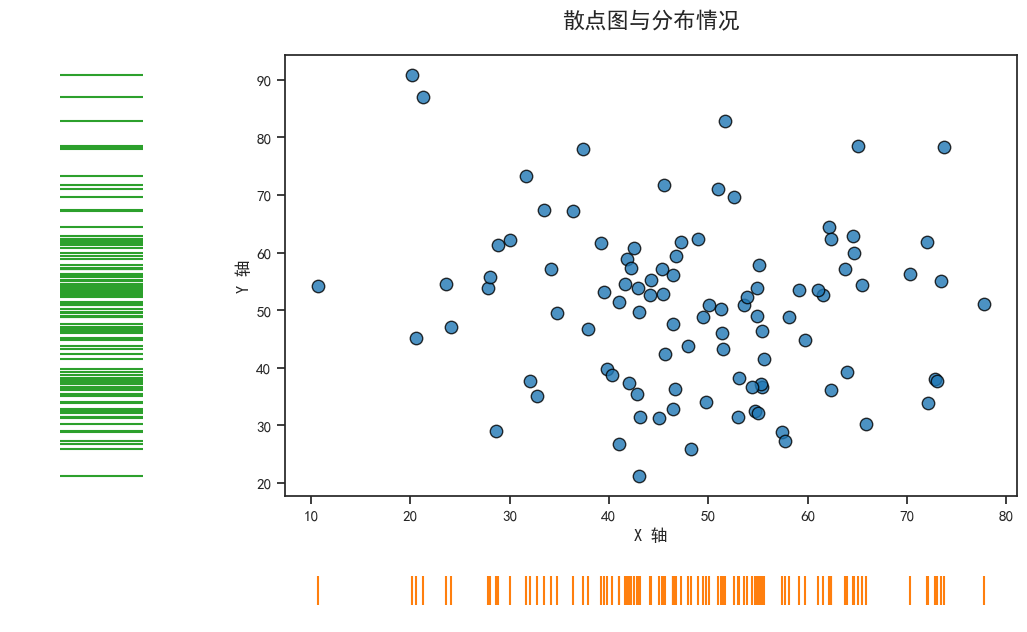

In [118]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.family'] = 'SimHei'

# 生成示例数据
np.random.seed(42)
x = np.random.normal(50, 15, 100)  # x 轴数据
y = np.random.normal(50, 15, 100)  # y 轴数据

# 创建画布和子图布局
fig = plt.figure(figsize=(13, 9))
# 使用 GridSpec 定义布局，调整行高比例
grid = plt.GridSpec(4, 4, hspace=0.5, wspace=0.5, height_ratios=[1, 3, 3, 1])

# 主散点图
ax_main = fig.add_subplot(grid[1:3, 1:4])  # 占据第1到第2行，第1到第3列
ax_main.scatter(x, y, color='#1f77b4', alpha=0.8, edgecolor='black', s=80)
ax_main.set_xlabel('X 轴', fontsize=12)
ax_main.set_ylabel('Y 轴', fontsize=12)
ax_main.set_title('散点图与分布情况', fontsize=16, pad=20)
# ax_main.set_xlim((0, 100))
# ax_main.set_ylim((0, 100))
print(ax_main.get_xlim())
# X 轴分布条形码（调整到下边）
ax_x_dist = fig.add_subplot(grid[3, 1:4])  # 占据第3行，第1到第3列
ax_x_dist.eventplot(x, orientation='horizontal', colors='#ff7f0e', lineoffsets=0.5, linelengths=0.8)
ax_x_dist.set_xlim(ax_main.get_xlim())  # 与主图 x 轴范围一致
# ax_x_dist.set_xlim((0, 100))  # 与主图 x 轴范围一致
ax_x_dist.axis('off')  # 隐藏坐标轴

# Y 轴分布条形码（调整到左边）
ax_y_dist = fig.add_subplot(grid[1:3, 0])  # 占据第1到第2行，第0列
ax_y_dist.eventplot(y, orientation='vertical', colors='#2ca02c', lineoffsets=0.5, linelengths=0.8)
ax_y_dist.set_ylim(ax_main.get_ylim())  # 与主图 y 轴范围一致
# ax_y_dist.set_ylim((0, 100))  # 与主图 y 轴范围一致
ax_y_dist.axis('off')  # 隐藏坐标轴

# 显示图形
plt.show()

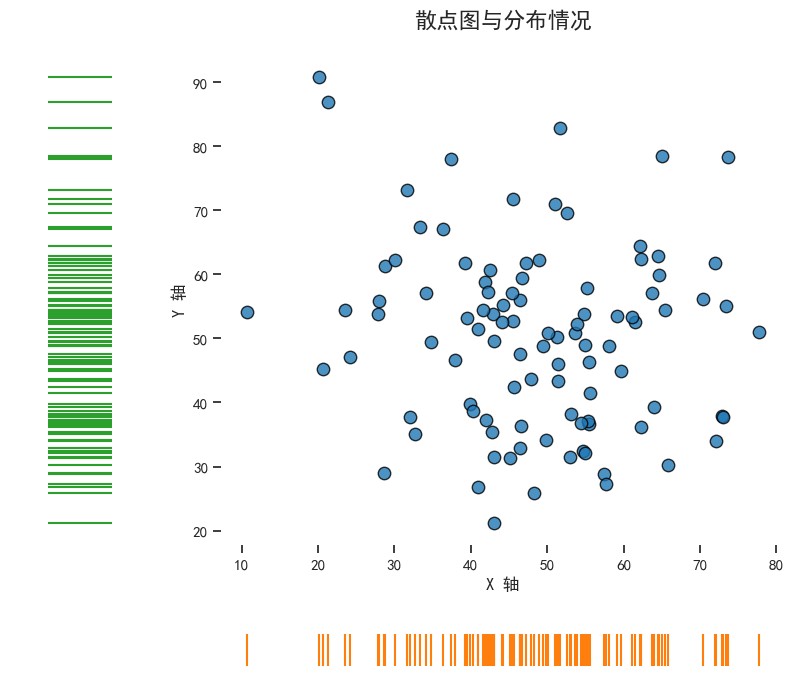

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.family'] = 'SimHei'

# 生成示例数据
np.random.seed(42)
x = np.random.normal(50, 15, 100)  # x 轴数据
y = np.random.normal(50, 15, 100)  # y 轴数据

# 创建画布和子图布局
fig = plt.figure(figsize=(10, 10))
# 使用 GridSpec 定义布局，调整行高比例
grid = plt.GridSpec(4, 4, hspace=0.5, wspace=0.5, height_ratios=[1, 3, 3, 1])

# 主散点图
ax_main = fig.add_subplot(grid[1:3, 1:4])  # 占据第1到第2行，第1到第3列
ax_main.scatter(x, y, color='#1f77b4', alpha=0.8, edgecolor='black', s=80)
ax_main.set_xlabel('X 轴', fontsize=12)
ax_main.set_ylabel('Y 轴', fontsize=12)
ax_main.set_title('散点图与分布情况', fontsize=16, pad=20)

# 显示主图的边框
for spine in ax_main.spines.values():
    spine.set_visible(False)  # 显示边框
    spine.set_edgecolor('black')  # 设置边框颜色
    spine.set_linewidth(1)  # 设置边框宽度

# X 轴分布条形码（调整到下边）
ax_x_dist = fig.add_subplot(grid[3, 1:4])  # 占据第3行，第1到第3列
ax_x_dist.eventplot(x, orientation='horizontal', colors='#ff7f0e', lineoffsets=0.5, linelengths=0.8)
ax_x_dist.set_xlim(ax_main.get_xlim())  # 与主图 x 轴范围一致
ax_x_dist.axis('off')  # 隐藏坐标轴

# Y 轴分布条形码（调整到左边）
ax_y_dist = fig.add_subplot(grid[1:3, 0])  # 占据第1到第2行，第0列
ax_y_dist.eventplot(y, orientation='vertical', colors='#2ca02c', lineoffsets=0.5, linelengths=0.8)
ax_y_dist.set_ylim(ax_main.get_ylim())  # 与主图 y 轴范围一致
ax_y_dist.axis('off')  # 隐藏坐标轴

# 显示图形
plt.show()

# 只显示坐标轴线

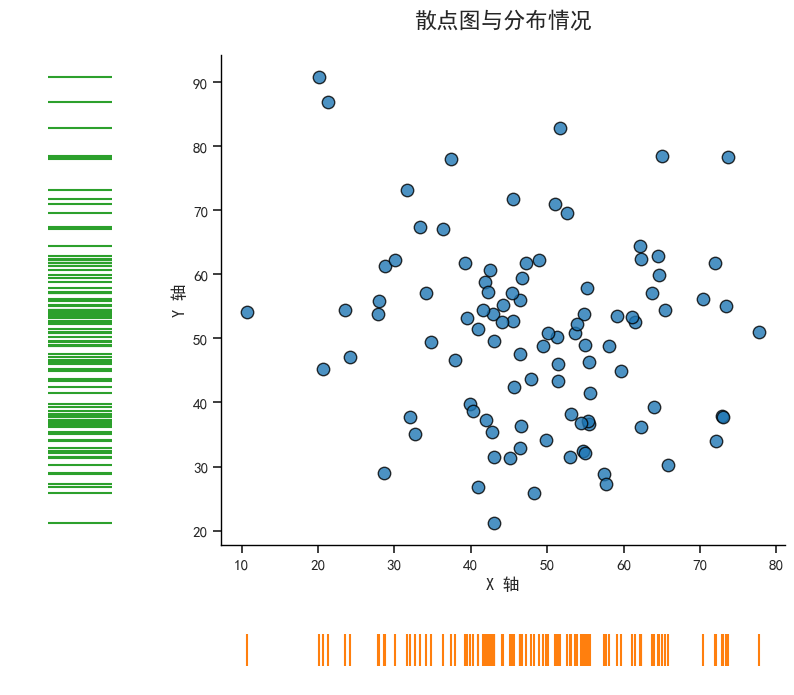

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.family'] = 'SimHei'

# 生成示例数据
np.random.seed(42)
x = np.random.normal(50, 15, 100)  # x 轴数据
y = np.random.normal(50, 15, 100)  # y 轴数据

# 创建画布和子图布局
fig = plt.figure(figsize=(10, 10))
# 使用 GridSpec 定义布局，调整行高比例
grid = plt.GridSpec(4, 4, hspace=0.5, wspace=0.5, height_ratios=[1, 3, 3, 1])

# 主散点图
ax_main = fig.add_subplot(grid[1:3, 1:4])  # 占据第1到第2行，第1到第3列
ax_main.scatter(x, y, color='#1f77b4', alpha=0.8, edgecolor='black', s=80)
ax_main.set_xlabel('X 轴', fontsize=12)
ax_main.set_ylabel('Y 轴', fontsize=12)
ax_main.set_title('散点图与分布情况', fontsize=16, pad=20)

# 只显示 x 轴和 y 轴的线，隐藏其他边框线
ax_main.spines['top'].set_visible(False)    # 隐藏上边框
ax_main.spines['right'].set_visible(False)  # 隐藏右边框
ax_main.spines['bottom'].set_visible(True)  # 显示下边框（x 轴）
ax_main.spines['left'].set_visible(True)    # 显示左边框（y 轴）

# 设置坐标轴线的样式
ax_main.spines['bottom'].set_color('black')  # 设置 x 轴线颜色
ax_main.spines['left'].set_color('black')    # 设置 y 轴线颜色
ax_main.spines['bottom'].set_linewidth(1)    # 设置 x 轴线宽度
ax_main.spines['left'].set_linewidth(1)      # 设置 y 轴线宽度

# X 轴分布条形码（调整到下边）
ax_x_dist = fig.add_subplot(grid[3, 1:4])  # 占据第3行，第1到第3列
ax_x_dist.eventplot(x, orientation='horizontal', colors='#ff7f0e', lineoffsets=0.5, linelengths=0.8)
ax_x_dist.set_xlim(ax_main.get_xlim())  # 与主图 x 轴范围一致
ax_x_dist.axis('off')  # 隐藏坐标轴

# Y 轴分布条形码（调整到左边）
ax_y_dist = fig.add_subplot(grid[1:3, 0])  # 占据第1到第2行，第0列
ax_y_dist.eventplot(y, orientation='vertical', colors='#2ca02c', lineoffsets=0.5, linelengths=0.8)
ax_y_dist.set_ylim(ax_main.get_ylim())  # 与主图 y 轴范围一致
ax_y_dist.axis('off')  # 隐藏坐标轴

# 显示图形
plt.show()

# 调整 GridSpec 布局参数

通过调整 GridSpec 的布局参数（如 height_ratios 和 width_ratios），可以更灵活地控制子图的位置和大小。

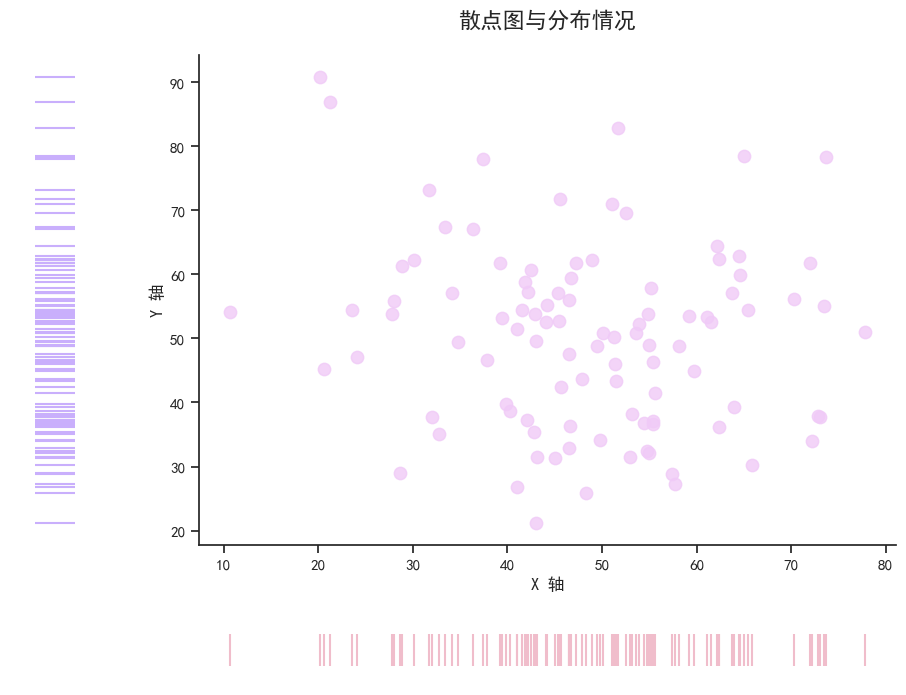

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.family'] = 'SimHei'

# 生成示例数据
np.random.seed(42)
x = np.random.normal(50, 15, 100)  # x 轴数据
y = np.random.normal(50, 15, 100)  # y 轴数据

# 创建画布和子图布局
fig = plt.figure(figsize=(14, 10))
# 使用 GridSpec 定义布局，调整行高和列宽比例
grid = plt.GridSpec(4, 4, hspace=0.5, wspace=0.5, height_ratios=[1, 3, 3, 1], width_ratios=[0.9, 3, 3, 1])

# 主散点图
ax_main = fig.add_subplot(grid[1:3, 1:3])  # 占据第1到第2行，第1到第2列
ax_main.scatter(x, y, color='#f0caf7', alpha=0.8, edgecolor='#f0caf7', s=80)
ax_main.set_xlabel('X 轴', fontsize=12)
ax_main.set_ylabel('Y 轴', fontsize=12)
ax_main.set_title('散点图与分布情况', fontsize=16, pad=20)

# 只显示 x 轴和 y 轴的线，隐藏其他边框线
ax_main.spines['top'].set_visible(False)    # 隐藏上边框
ax_main.spines['right'].set_visible(False)  # 隐藏右边框
ax_main.spines['bottom'].set_visible(True)  # 显示下边框（x 轴）
ax_main.spines['left'].set_visible(True)    # 显示左边框（y 轴）

# X 轴分布条形码（调整到下边）
ax_x_dist = fig.add_subplot(grid[3, 1:3])  # 占据第3行，第1到第2列
ax_x_dist.eventplot(x, orientation='horizontal', colors='#f0bdcb', lineoffsets=0.5, linelengths=0.8)
ax_x_dist.set_xlim(ax_main.get_xlim())  # 与主图 x 轴范围一致
ax_x_dist.axis('off')  # 隐藏坐标轴

# Y 轴分布条形码（调整到左边，自定义位置）
ax_y_dist = fig.add_subplot(grid[1:3, 0])  # 占据第1到第2行，第0列
ax_y_dist.eventplot(y, orientation='vertical', colors='#c9affc', lineoffsets=0.5, linelengths=0.8)
ax_y_dist.set_ylim(ax_main.get_ylim())  # 与主图 y 轴范围一致
ax_y_dist.axis('off')  # 隐藏坐标轴

# 显示图形
plt.show()

# 使用 fig.add_axes 手动指定条形图位置

通过 fig.add_axes，可以手动指定子图的位置和大小。位置参数是一个四元组 [left, bottom, width, height]，表示子图在画布中的相对位置和大小。

设置坐标轴的颜色和线型：
使用 ax_main.spines.values() 遍历所有坐标轴线（上、下、左、右）。
通过 spine.set_color('red') 设置坐标轴线颜色为红色。
通过 spine.set_linewidth(2) 设置坐标轴线宽度为 2。
通过 spine.set_linestyle('--') 设置坐标轴线型为虚线。

设置刻度线的颜色和线型：

使用 ax_main.tick_params 设置刻度线的样式：
axis='both'：同时设置 x 轴和 y 轴的刻度线。
which='both'：同时设置主刻度线和次刻度线。
colors='blue'：设置刻度线颜色为蓝色。
width=2：设置刻度线宽度为 2。
length=6：设置刻度线长度为 6。
direction='inout'：设置刻度线方向为内外双向。


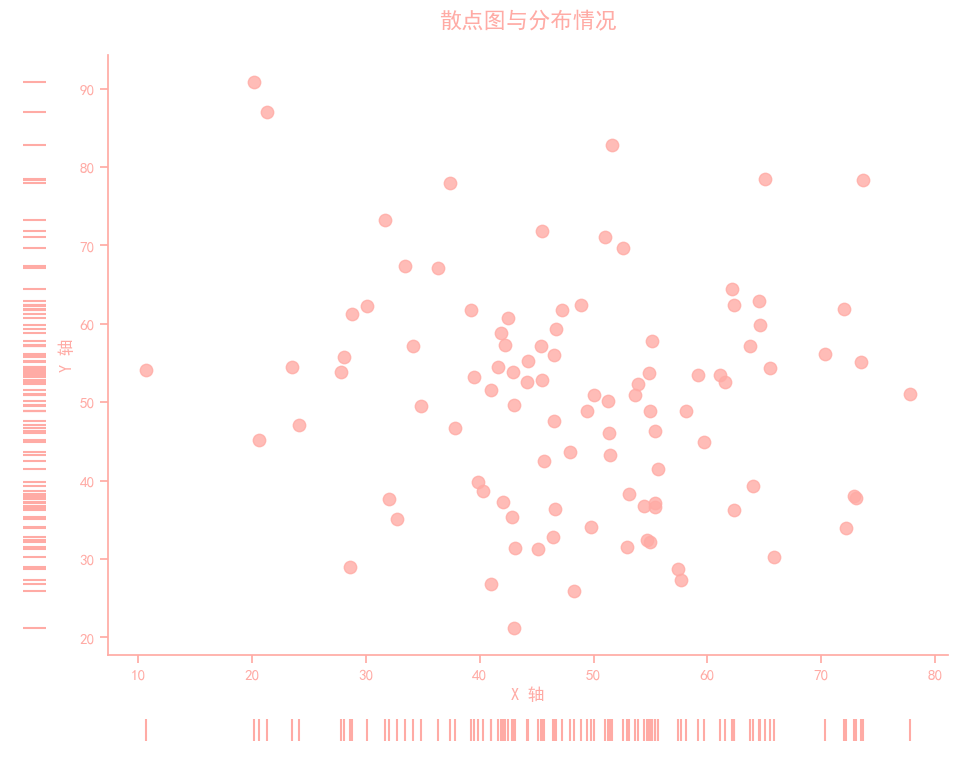

In [113]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.family'] = 'SimHei'

# 生成示例数据
np.random.seed(42)
x = np.random.normal(50, 15, 100)  # x 轴数据
y = np.random.normal(50, 15, 100)  # y 轴数据

color = '#ffaba5'
# 创建画布
fig = plt.figure(figsize=(14, 10))

# 主散点图
ax_main = fig.add_axes([0.1, 0.3, 0.6, 0.6])  # 手动指定位置和大小
ax_main.scatter(x, y, color=color, alpha=0.8, edgecolor=color, s=80)
ax_main.set_xlabel('X 轴', fontsize=12, color=color)
ax_main.set_ylabel('Y 轴', fontsize=12, color=color)
ax_main.set_title('散点图与分布情况', fontsize=16, pad=20, color=color)

# 只显示 x 轴和 y 轴的线，隐藏其他边框线
ax_main.spines['top'].set_visible(False)    # 隐藏上边框
ax_main.spines['right'].set_visible(False)  # 隐藏右边框
ax_main.spines['bottom'].set_visible(True)  # 显示下边框（x 轴）
ax_main.spines['bottom'].set_color(color)  # 显示下边框（x 轴）
ax_main.spines['left'].set_visible(True)    # 显示左边框（y 轴）
ax_main.spines['left'].set_color(color)  # 显示下边框（x 轴）
ax_main.tick_params(colors=color)
# X 轴分布条形码（调整到下边）
ax_x_dist = fig.add_axes([0.1, 0.2, 0.6, 0.05])  # 手动指定位置和大小
ax_x_dist.eventplot(x, orientation='horizontal', colors=color, lineoffsets=0.5, linelengths=0.8)
ax_x_dist.set_xlim(ax_main.get_xlim())  # 与主图 x 轴范围一致
ax_x_dist.axis('off')  # 隐藏坐标轴

# Y 轴分布条形码（调整到左边，自定义位置）
ax_y_dist = fig.add_axes([0.03, 0.3, 0.035, 0.6])  # 手动指定位置和大小
ax_y_dist.eventplot(y, orientation='vertical', colors=color, lineoffsets=0.5, linelengths=0.8)
ax_y_dist.set_ylim(ax_main.get_ylim())  # 与主图 y 轴范围一致
ax_y_dist.axis('off')  # 隐藏坐标轴

# 显示图形
plt.savefig('scatter_3.png', dpi=400)
plt.show()